# SmartCart Customer Segmentation using Machine Learning

## Project Introduction

Customer segmentation is a crucial strategy for modern e-commerce platforms. Instead of treating all customers the same, businesses can group customers based on their behavior and target them with personalized marketing strategies.

In this project, we build a **Customer Segmentation System** for SmartCart, an e-commerce platform that has collected detailed customer information such as demographics, purchase history, website activity, and engagement metrics.

Using **unsupervised machine learning techniques**, the goal is to analyze this data and automatically group customers into meaningful clusters based on their purchasing behavior and engagement patterns.

These customer segments can help businesses:

* Identify **high-value customers**
* Detect **inactive or churn-risk users**
* Design **targeted marketing campaigns**
* Improve **customer retention and engagement**

The project follows a complete machine learning pipeline including **data preprocessing, feature engineering, dimensionality reduction, clustering, and cluster analysis** to extract actionable insights from customer data.


## Dataset Overview

The SmartCart dataset contains customer information collected from an e-commerce platform.
Each row represents a single customer, and the columns describe demographic details, purchasing behavior, and engagement activity.

The dataset includes **2240 customer records** and multiple attributes that can help identify patterns in customer behavior.

### Main Feature Groups

**1. Customer Demographics**

* `Year_Birth` – Birth year of the customer
* `Education` – Highest education level
* `Marital_Status` – Marital status
* `Income` – Yearly household income
* `Kidhome` – Number of children in household
* `Teenhome` – Number of teenagers in household
* `Dt_Customer` – Date when the customer joined the platform

**2. Purchase Behavior (Amount Spent)**

* `MntWines`
* `MntFruits`
* `MntMeatProducts`
* `MntFishProducts`
* `MntSweetProducts`
* `MntGoldProds`

These features represent the **total amount spent in different product categories**.

**3. Purchase Behavior (Frequency)**

* `NumDealsPurchases`
* `NumWebPurchases`
* `NumCatalogPurchases`
* `NumStorePurchases`
* `NumWebVisitsMonth`

These indicate **how customers interact with different purchase channels**.

**4. Customer Engagement**

* `Recency` – Number of days since last purchase
* `Complain` – Whether the customer complained in the last 2 years

Using this dataset, we aim to identify **distinct customer groups based on their behavior and engagement patterns**.


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [19]:
df = pd.read_csv("smartcart_customers.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Data Exploration

Before applying any machine learning techniques, it is important to understand the structure and characteristics of the dataset.

In this section, we perform some basic exploratory steps to get an overview of the data. This helps us identify potential issues such as missing values, incorrect data types, or unusual distributions.

The following checks are performed:

* Dataset shape (number of rows and columns)
* Column information and data types
* Missing values
* Statistical summary of numerical features

These steps help us better understand the dataset before moving to data preprocessing and feature engineering.


In [20]:
# Check number of rows and columns in the dataset
df.shape

(2240, 22)

In [21]:
# Display column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [22]:
# Count missing values in each column
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [23]:
# Summary statistics for numerical columns
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [24]:
# List all column names
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

## Data Preprocessing

Raw datasets often contain missing values or inconsistent data formats that must be handled before applying machine learning algorithms.

In this section, we perform basic preprocessing steps to clean and prepare the dataset for further analysis.

### Steps performed

1. **Handling Missing Values**

   * The `Income` column contains a few missing values.
   * Since income data may contain outliers, we fill missing values using the **median**, which is more robust than the mean.

2. **Date Conversion**

   * The `Dt_Customer` column represents the date when the customer joined the platform.
   * It is converted into a proper **datetime format** to enable time-based feature engineering later in the analysis.

These preprocessing steps ensure that the dataset is clean and ready for feature engineering.


In [25]:
# Check missing values again before handling
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [26]:
# Fill missing values in Income using the median
# Median is used because income distribution may contain outliers
df["Income"] = df["Income"].fillna(df["Income"].median())

In [28]:
# Convert Dt_Customer to datetime format
# The dataset stores dates in DD-MM-YYYY format, so we specify dayfirst=True
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

In [31]:
# Confirm there are no remaining missing values
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
Customer_Year          0
dtype: int64

## Feature Engineering

Feature engineering involves creating new meaningful variables from existing data to improve the performance of machine learning models.

Instead of directly using raw attributes, we derive additional features that better represent customer characteristics and behavior. These engineered features help the clustering algorithm identify clearer patterns among customers.

In this section, we create the following features:

* **Age** – derived from the customer's birth year.
* **Customer Tenure** – number of days since the customer joined the platform.
* **Total Spending** – total amount spent across all product categories.
* **Total Children** – total number of children in the household.
* **Living_With** – simplified marital status to indicate whether the customer lives with a partner or alone.

These features provide a more comprehensive representation of each customer's lifestyle and purchasing behavior.


In [32]:
# Calculate customer age using birth year
df["Age"] = 2026 - df["Year_Birth"]

df["Age"].head()

0    69
1    72
2    61
3    42
4    45
Name: Age, dtype: int64

In [33]:
# Calculate how long the customer has been with the company
# Tenure is calculated as number of days since enrollment

latest_date = df["Dt_Customer"].max()

df["Customer_Tenure"] = (latest_date - df["Dt_Customer"]).dt.days

In [34]:
# Calculate total amount spent by each customer across all product categories

df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

df["Total_Spending"].head()

0    1617
1      27
2     776
3      53
4     422
Name: Total_Spending, dtype: int64

In [35]:
# Combine number of kids and teenagers in the household

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [36]:
# Simplify marital status into two categories

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "YOLO": "Alone",
    "Absurd": "Alone"
})

In [37]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Year,Age,Customer_Tenure,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,1,2012,69,663,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,2014,72,113,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,2013,61,312,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,2014,42,139,53,1,Partner
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,2014,45,161,422,1,Partner


## Feature Selection

After creating new features, some of the original columns become redundant or unnecessary for clustering.

For example:

* **`ID`** is only a unique identifier and does not provide meaningful information for clustering.
* **`Year_Birth`** is no longer required since we created the `Age` feature.
* **`Kidhome`** and **`Teenhome`** were combined into `Total_Children`.
* **`Marital_Status`** was simplified into the `Living_With` feature.
* **`Dt_Customer`** was used to compute customer tenure and is no longer required.

Removing these columns helps reduce dimensionality and prevents the clustering algorithm from being influenced by irrelevant attributes.


In [38]:
# Drop columns that are no longer needed after feature engineering

columns_to_drop = [
    "ID",
    "Year_Birth",
    "Kidhome",
    "Teenhome",
    "Marital_Status",
    "Dt_Customer"
]

df = df.drop(columns=columns_to_drop)

In [39]:
df.head()

,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Year,Age,Customer_Tenure,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,635,88,546,172,88,88,3,...,4,7,0,1,2012,69,663,1617,0,Alone
1,Graduation,46344.0,38,11,1,6,2,1,6,2,...,2,5,0,0,2014,72,113,27,2,Alone
2,Graduation,71613.0,26,426,49,127,111,21,42,1,...,10,4,0,0,2013,61,312,776,0,Partner
3,Graduation,26646.0,26,11,4,20,10,3,5,2,...,4,6,0,0,2014,42,139,53,1,Partner
4,PhD,58293.0,94,173,43,118,46,27,15,5,...,6,5,0,0,2014,45,161,422,1,Partner


In [40]:
df.columns

Index(['Education', 'Income', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Customer_Year', 'Age', 'Customer_Tenure',
       'Total_Spending', 'Total_Children', 'Living_With'],
      dtype='str')

## Outlier Detection

Outliers are extreme values that differ significantly from the rest of the dataset. These values can negatively affect machine learning models, especially clustering algorithms like K-Means, which rely on distance calculations.

In this section, we identify potential outliers in important numerical features such as **Age**, **Income**, and **Total Spending** using visualization techniques.

Boxplots are used to visually detect extreme values and understand the distribution of the data. If necessary, unrealistic values will be removed to improve the quality of the dataset.

Handling outliers ensures that the clustering algorithm can identify meaningful patterns without being biased by abnormal data points.


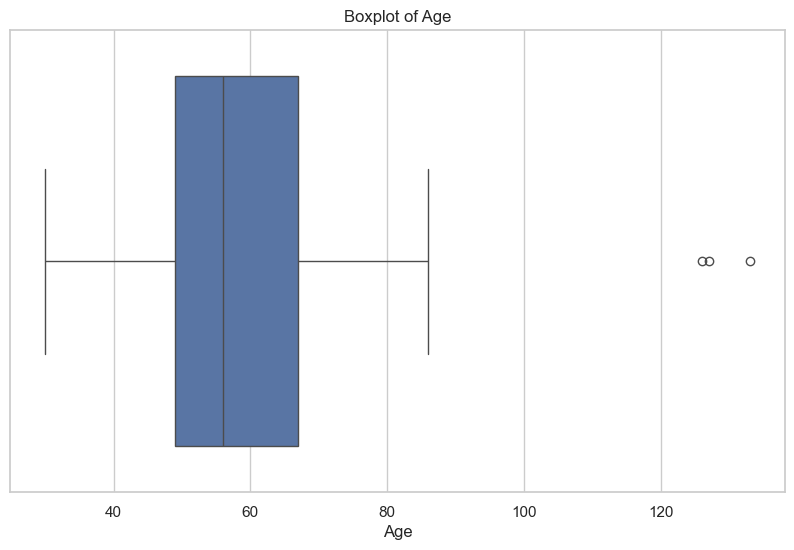

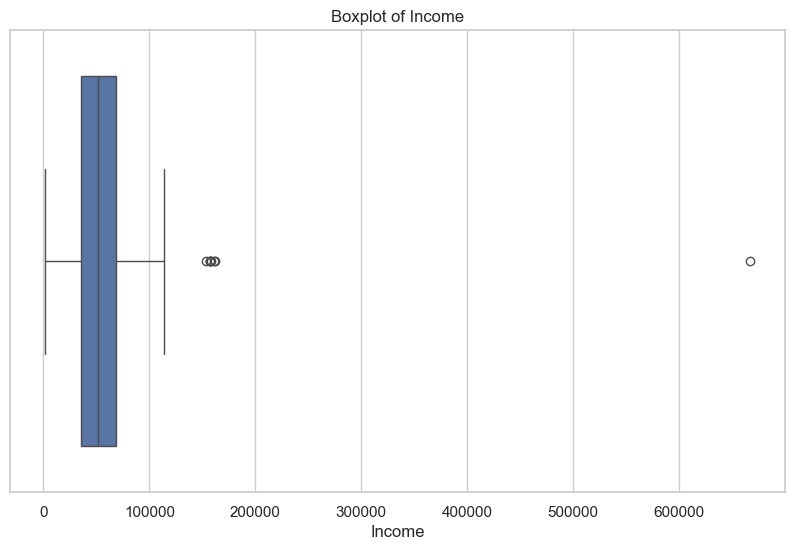

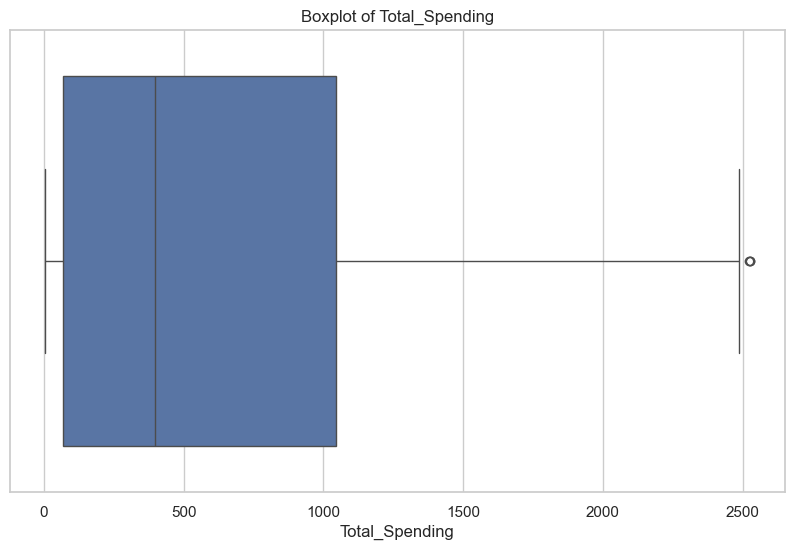

In [41]:
# Select important numerical features for outlier detection
num_cols = ["Age", "Income", "Total_Spending"]

# Plot boxplots
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Outlier Observations

From the boxplots above, we observe the following:

* A few customers have **unrealistically high ages (above 100 years)**, which likely result from data entry errors.
* The **Income** feature contains a few extremely high values that may distort clustering results.
* The **Total_Spending** feature shows some high values, but these represent potential high-value customers and are therefore retained.

To improve clustering performance, we remove unrealistic values from the **Age** and **Income** features while keeping the spending values intact.


In [46]:
# Remove unrealistic age values
df = df[df["Age"] < 90]

# Remove extreme income outliers
df = df[df["Income"] < 600000]

# Check updated dataset shape
df.shape

(2236, 22)

In [50]:
df.shape

(2236, 22)

In [51]:
df.describe()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Year,Age,Customer_Tenure,Total_Spending,Total_Children
count,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,51952.614043,49.116279,304.12746,26.275939,166.983453,37.536225,27.080501,43.983005,2.326029,4.087657,2.663238,5.795617,5.318873,0.008945,0.149374,2013.027728,57.101968,353.773256,605.986583,0.950805
std,21411.466851,28.957284,336.59181,39.724007,225.689645,54.648562,41.299504,52.061568,1.933032,2.779988,2.923898,3.251129,2.426886,0.094173,0.356536,0.684857,11.703281,202.181561,601.865156,0.752204
min,1730.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2012.000000,30.000000,0.000000,5.000000,0.000000
25%,35502.500000,24.000000,24.00000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,2013.000000,49.000000,180.750000,69.000000,0.000000
50%,51381.500000,49.000000,174.00000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,2013.000000,56.000000,356.000000,396.500000,1.000000
75%,68275.750000,74.000000,504.25000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,2013.000000,67.000000,529.000000,1045.500000,1.000000
max,162397.000000,99.000000,1493.00000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,2014.000000,86.000000,699.000000,2525.000000,3.000000


## Correlation Analysis

Before applying clustering algorithms, it is useful to understand how different numerical features relate to each other.

Correlation analysis helps identify relationships between variables such as **income, spending behavior, purchase frequency, and website activity**.

A **correlation matrix** is used to measure the strength of relationships between features, where:

* Values close to **1** indicate strong positive correlation
* Values close to **-1** indicate strong negative correlation
* Values near **0** indicate little or no relationship

To visualize these relationships, we use a **heatmap**, which makes it easier to identify patterns and dependencies between features.

Understanding these relationships can provide insights into customer behavior and guide feature selection for clustering.


In [52]:
# Select numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Year,Age,Customer_Tenure,Total_Spending,Total_Children
Income,1.000000,0.007829,0.686080,0.504911,0.684176,0.518462,0.518126,0.383548,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.026504,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,0.016321,-0.003717,0.023446,0.001314,0.022796,0.017168,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,-0.025544,0.019396,0.024238,0.020842,0.017826
MntWines,0.686080,0.016321,1.000000,0.388472,0.561886,0.398956,0.385845,0.386234,0.011173,0.542136,0.634716,0.642313,-0.320287,-0.035974,0.247280,-0.153847,0.162809,0.166068,0.891696,-0.351522
MntFruits,0.504911,-0.003717,0.388472,1.000000,0.542030,0.594415,0.567030,0.389999,-0.131792,0.296986,0.487274,0.463136,-0.417405,-0.002813,0.125854,-0.054834,0.013657,0.067104,0.613122,-0.394121
MntMeatProducts,0.684176,0.023446,0.561886,0.542030,1.000000,0.567813,0.523329,0.348727,-0.122242,0.293502,0.723473,0.479983,-0.539183,-0.020750,0.236548,-0.082130,0.030729,0.092605,0.842624,-0.501844
MntFishProducts,0.518462,0.001314,0.398956,0.594415,0.567813,1.000000,0.579490,0.422018,-0.139263,0.293424,0.533969,0.459997,-0.445729,-0.018842,0.111325,-0.067321,0.042359,0.080636,0.642335,-0.425148
MntSweetProducts,0.518126,0.022796,0.385845,0.567030,0.523329,0.579490,1.000000,0.369084,-0.120064,0.348236,0.490416,0.448673,-0.423215,-0.020432,0.117263,-0.073020,0.019379,0.081012,0.602610,-0.382882
MntGoldProds,0.383548,0.017168,0.386234,0.389999,0.348727,0.422018,0.369084,1.000000,0.050192,0.422673,0.436909,0.383124,-0.249041,-0.029902,0.140595,-0.142454,0.057419,0.160189,0.522653,-0.264964
NumDealsPurchases,-0.107169,-0.000638,0.011173,-0.131792,-0.122242,-0.139263,-0.120064,0.050192,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,-0.185958,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.542136,0.296986,0.293502,0.293424,0.348236,0.422673,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,-0.166722,0.153873,0.191211,0.519948,-0.146429


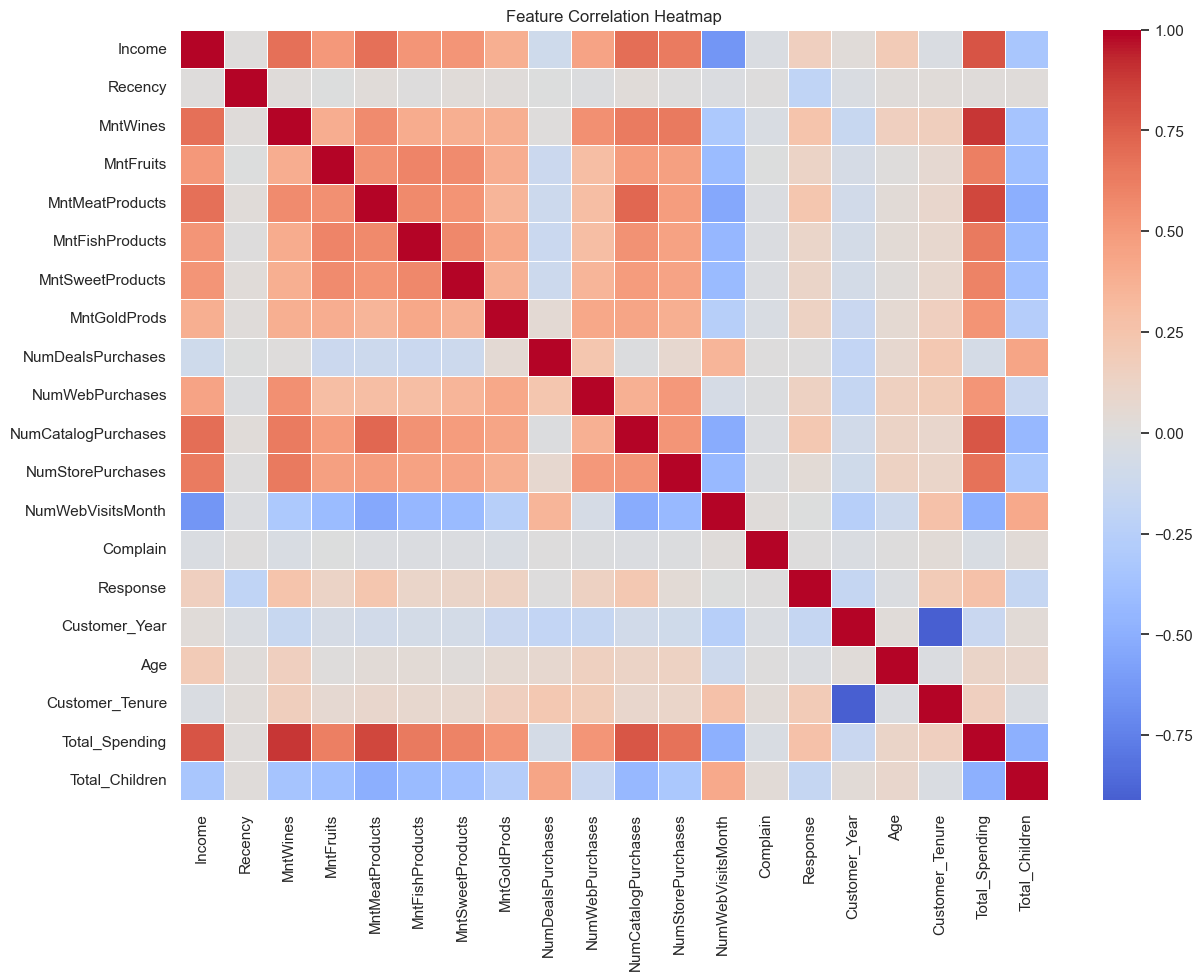

In [55]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Insights

The correlation heatmap above provides insights into relationships between different customer features.

Some key observations include:

* **Total_Spending** shows strong positive correlations with product purchase features such as `MntWines`, `MntMeatProducts`, and `MntFishProducts`, which is expected since it is derived from these variables.

* **Income** shows moderate positive correlation with several spending features, indicating that customers with higher income tend to spend more.

* **Purchase frequency features** such as `NumWebPurchases`, `NumCatalogPurchases`, and `NumStorePurchases` show positive relationships with spending behavior, suggesting that frequent buyers tend to spend more overall.

* **NumWebVisitsMonth** appears negatively correlated with some purchase features, which may indicate that customers who browse frequently do not always convert into buyers.

Overall, the dataset contains meaningful relationships between spending behavior, income, and purchasing activity, which will help clustering algorithms identify distinct customer segments.


## Encoding Categorical Variables

Machine learning algorithms require numerical input features. However, the dataset contains categorical variables such as **Education** and **Living_With**, which represent text-based categories.

To convert these variables into a format suitable for machine learning models, we apply **One-Hot Encoding**.

One-Hot Encoding transforms each category into a separate binary column where:

* `1` indicates the presence of that category
* `0` indicates its absence

This approach avoids introducing artificial ordinal relationships between categories and allows clustering algorithms to interpret the features correctly.


In [56]:
# Select categorical features
categorical_cols = ["Education", "Living_With"]

categorical_cols

['Education', 'Living_With']

In [57]:
# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols)

In [58]:
df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Customer_Tenure,Total_Spending,Total_Children,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Living_With_Alone,Living_With_Partner
0,58138.0,58,635,88,546,172,88,88,3,8,...,663,1617,0,False,False,True,False,False,True,False
1,46344.0,38,11,1,6,2,1,6,2,1,...,113,27,2,False,False,True,False,False,True,False
2,71613.0,26,426,49,127,111,21,42,1,8,...,312,776,0,False,False,True,False,False,False,True
3,26646.0,26,11,4,20,10,3,5,2,2,...,139,53,1,False,False,True,False,False,False,True
4,58293.0,94,173,43,118,46,27,15,5,5,...,161,422,1,False,False,False,False,True,False,True


In [59]:
df.shape

(2236, 27)

## Feature Scaling

Clustering algorithms such as **K-Means** rely on distance-based calculations to group similar data points. If the dataset contains features with very different scales, features with larger numerical ranges can dominate the clustering process.

For example:

* `Income` values can reach **hundreds of thousands**
* `Recency` may be in **days**
* `Age` is typically between **20–80**

Without scaling, the algorithm may focus more on features with larger values and ignore smaller ones.

To address this issue, we apply **Standardization** using `StandardScaler`, which transforms the data so that:

* The **mean becomes 0**
* The **standard deviation becomes 1**

This ensures that all features contribute equally to the clustering process.


In [60]:
# Create a copy of the dataset for scaling
X = df.copy()

In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [63]:
# Convert Scaled Data Back to DataFrame

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Customer_Tenure,Total_Spending,Total_Children,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Living_With_Alone,Living_With_Partner
0,0.288947,0.306856,0.983228,1.554170,1.679746,2.461068,1.475396,0.845669,0.348738,1.407639,...,1.529793,1.680176,-1.264308,-0.314279,-0.157315,0.992870,-0.445292,-0.526293,1.347635,-1.347635
1,-0.262003,-0.383971,-0.871064,-0.636431,-0.713455,-0.650414,-0.631638,-0.729742,-0.168700,-1.110921,...,-1.191143,-0.962202,1.395139,-0.314279,-0.157315,0.992870,-0.445292,-0.526293,1.347635,-1.347635
2,0.918423,-0.798467,0.362159,0.572177,-0.177201,1.344595,-0.147262,-0.038098,-0.686137,1.407639,...,-0.206659,0.282541,-1.264308,-0.314279,-0.157315,0.992870,-0.445292,-0.526293,-0.742041,0.742041
3,-1.182183,-0.798467,-0.871064,-0.560893,-0.651409,-0.503991,-0.583200,-0.748954,-0.168700,-0.751127,...,-1.062517,-0.918994,0.065416,-0.314279,-0.157315,0.992870,-0.445292,-0.526293,-0.742041,0.742041
4,0.296187,1.550344,-0.389661,0.421101,-0.217088,0.154911,-0.001950,-0.556831,1.383614,0.328256,...,-0.953679,-0.305762,0.065416,-0.314279,-0.157315,-1.007181,-0.445292,1.900081,-0.742041,0.742041


In [64]:
X_scaled.describe()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Customer_Tenure,Total_Spending,Total_Children,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Living_With_Alone,Living_With_Partner
count,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2236.000000,...,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,-7.785464e-17,-7.149916e-17,-7.944351e-18,-5.561046e-18,-3.177740e-17,4.289949e-17,2.065531e-17,4.766610e-18,1.271096e-17,0.000000,...,2.542192e-17,4.766610e-18,7.944351e-17,2.859966e-17,2.859966e-17,-9.533221e-17,-9.692108e-17,-2.859966e-17,-6.355481e-18,9.692108e-17
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224,...,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.346119e+00,-1.696543e+00,-9.037519e-01,-6.616104e-01,-7.400464e-01,-6.870194e-01,-6.558568e-01,-8.450157e-01,-1.203575e+00,-1.470716,...,-1.750171e+00,-9.987636e-01,-1.264308e+00,-3.142793e-01,-1.573148e-01,-1.007181e+00,-4.452922e-01,-5.262932e-01,-7.420405e-01,-1.347635e+00
25%,-7.684571e-01,-8.675502e-01,-8.324330e-01,-6.364311e-01,-6.691367e-01,-6.321109e-01,-6.316380e-01,-6.721048e-01,-6.861374e-01,-0.751127,...,-8.559730e-01,-8.924037e-01,-1.264308e+00,-3.142793e-01,-1.573148e-01,-1.007181e+00,-4.452922e-01,-5.262932e-01,-7.420405e-01,-1.347635e+00
50%,-2.667925e-02,-4.016436e-03,-3.866896e-01,-4.601758e-01,-4.431121e-01,-4.673854e-01,-4.621065e-01,-3.839200e-01,-1.686996e-01,-0.031538,...,1.101605e-02,-3.481402e-01,6.541573e-02,-3.142793e-01,-1.573148e-01,9.928698e-01,-4.452922e-01,-5.262932e-01,-7.420405e-01,7.420405e-01
75%,7.625254e-01,8.595173e-01,5.946886e-01,1.693073e-01,2.881439e-01,2.281224e-01,1.433631e-01,2.308744e-01,3.487383e-01,0.688050,...,8.668740e-01,7.304157e-01,6.541573e-02,-3.142793e-01,-1.573148e-01,9.928698e-01,-4.452922e-01,-5.262932e-01,1.347635e+00,7.420405e-01
max,5.159343e+00,1.723051e+00,3.532880e+00,4.349075e+00,6.904903e+00,4.053415e+00,5.713683e+00,6.109845e+00,6.557993e+00,8.243731,...,1.707891e+00,3.189157e+00,2.724862e+00,3.181883e+00,6.356682e+00,9.928698e-01,2.245717e+00,1.900081e+00,1.347635e+00,7.420405e-01


## Dimensionality Reduction using PCA

After encoding categorical variables and scaling the dataset, the number of features increases significantly. High-dimensional data can make visualization and clustering more difficult.

To address this, we apply **Principal Component Analysis (PCA)**.

PCA is a dimensionality reduction technique that transforms the original features into a smaller set of new variables called **principal components**. These components capture most of the variance present in the dataset.

Benefits of using PCA:

* Reduces the dimensionality of the dataset
* Removes redundancy among correlated features
* Improves computational efficiency
* Allows visualization of clusters in **2D or 3D space**

In this project, we reduce the dataset to **3 principal components** for visualization and clustering.


In [65]:
# Apply PCA to reduce dimensions
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [67]:
#Convert PCA Output to DataFrame

X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])

X_pca.head()

,PC1,PC2,PC3
0,4.644009,2.590039,2.242173
1,-2.577795,-1.656297,1.886644
2,1.894608,-0.563385,-1.000856
3,-2.620884,-1.686121,-0.636928
4,-0.304100,-1.053904,-1.305605


In [68]:
pca.explained_variance_ratio_

array([0.26353242, 0.08907366, 0.07605921])

In [69]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.42866529269972725)

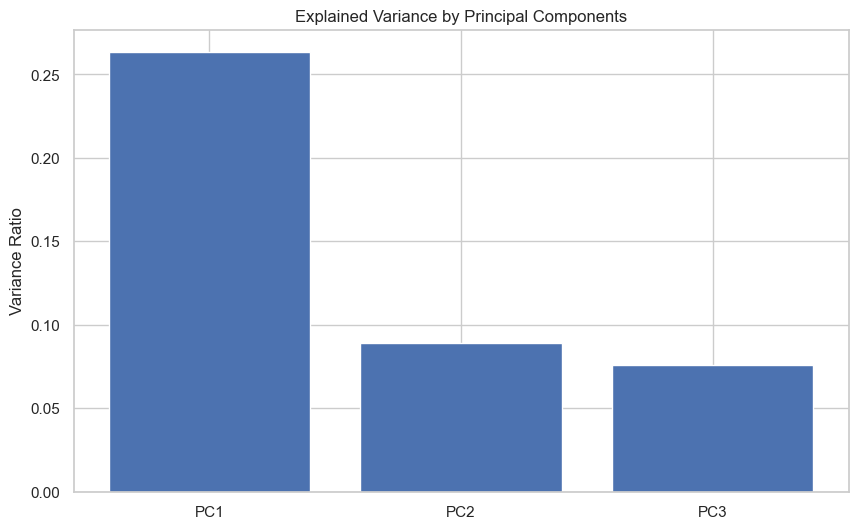

In [72]:
plt.figure()

plt.bar(
    ["PC1","PC2","PC3"],
    pca.explained_variance_ratio_
)

plt.title("Explained Variance by Principal Components")
plt.ylabel("Variance Ratio")

plt.show()

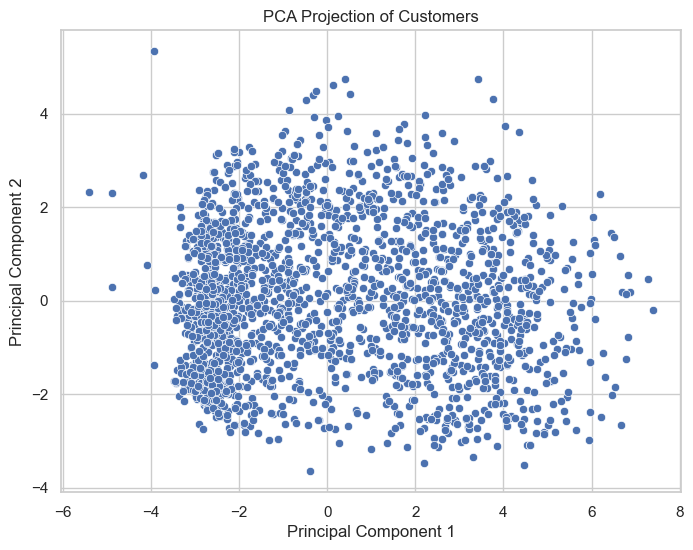

In [73]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"]
)

plt.title("PCA Projection of Customers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

### PCA Interpretation

The PCA projection above shows the distribution of customers in a reduced feature space using the first two principal components.

The first three principal components capture approximately **43% of the total variance** in the dataset. While this does not represent the entire dataset information, it is sufficient for visualization and dimensionality reduction.

From the scatter plot, the data points appear widely distributed with some dense regions. This indicates that customer groups are not clearly separated in a simple linear space, making clustering algorithms useful for discovering hidden patterns in the data.

PCA helps simplify the dataset while retaining important information, allowing us to apply clustering algorithms more efficiently.


## Finding the Optimal Number of Clusters

Before applying clustering algorithms such as **K-Means**, we must determine the appropriate number of clusters (`K`).

Selecting the correct number of clusters ensures that the model captures meaningful patterns in the data without overfitting or oversimplifying the segmentation.

In this project, we use two commonly used techniques:

### 1. Elbow Method

The Elbow Method evaluates clustering performance by calculating the **Within-Cluster Sum of Squares (WCSS)** for different values of K.

As K increases, WCSS decreases because clusters become more compact. The optimal value of K is typically found at the **"elbow point"**, where the rate of decrease slows down.

### 2. Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters.

* Values close to **1** indicate well-separated clusters
* Values near **0** indicate overlapping clusters
* Negative values indicate incorrect clustering

By combining insights from both methods, we can select a suitable number of clusters for the dataset.


In [74]:
wcss = []

for k in range(1, 11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

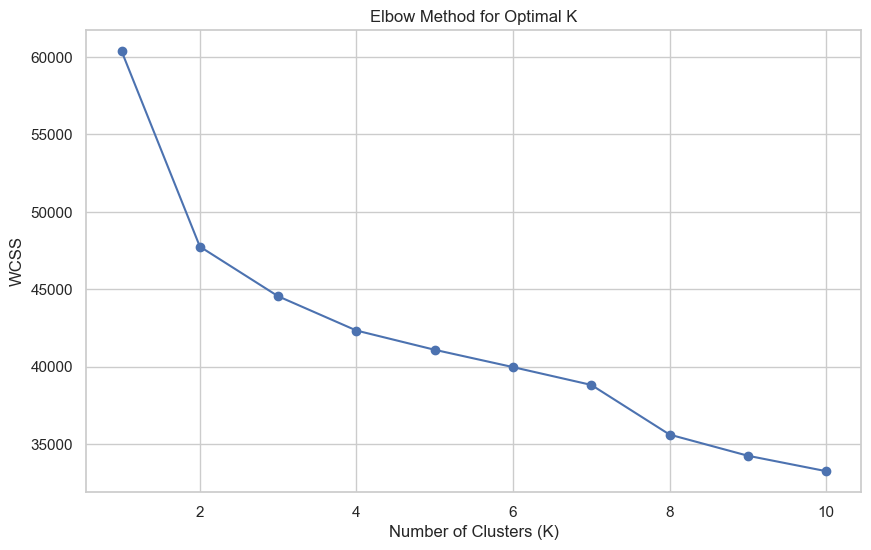

In [75]:
plt.figure()

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [76]:
silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

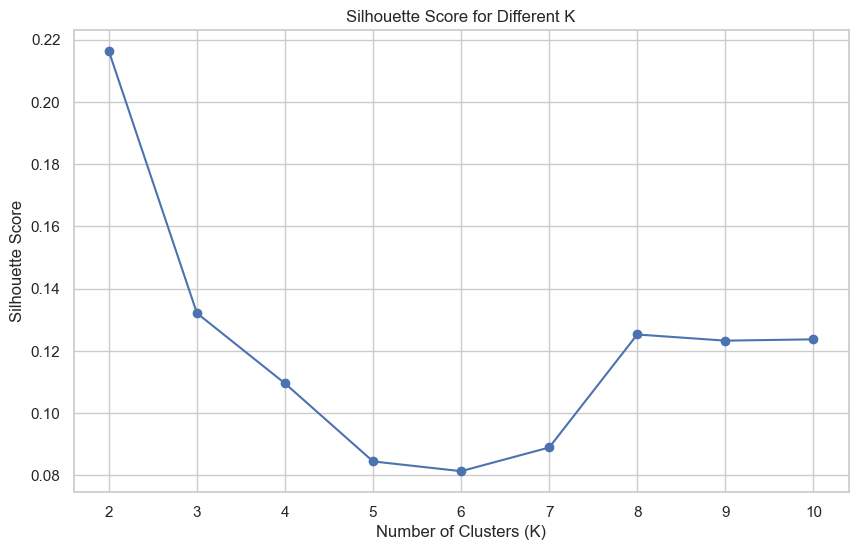

In [77]:
plt.figure()

plt.plot(range(2,11), silhouette_scores, marker="o")

plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()

### Selecting the Optimal Number of Clusters

Based on the Elbow Method and Silhouette Score analysis:

* The **Elbow Method** shows a noticeable bend around **K = 3–4**, indicating that adding more clusters beyond this point provides diminishing improvement.
* The **Silhouette Score** is highest at **K = 2**, but this would produce overly broad clusters that may not provide meaningful customer segmentation.

Considering both methods and the goal of creating useful customer segments, we select **K = 4 clusters** as the optimal number.

Using four clusters allows the model to capture meaningful differences in customer behavior while keeping the segmentation interpretable for business applications.


## Clustering Models

After determining the optimal number of clusters, we now apply clustering algorithms to segment the customers into meaningful groups.

In this project, we use two clustering techniques:

### 1. K-Means Clustering

K-Means is a centroid-based clustering algorithm that groups data points based on their distance from cluster centers. The algorithm iteratively updates the cluster centroids until the clusters stabilize.

### 2. Agglomerative Hierarchical Clustering

Agglomerative clustering is a hierarchical approach that starts with each data point as its own cluster and progressively merges clusters based on similarity.

Using multiple clustering techniques allows us to compare results and ensure the segmentation is robust.

Based on the previous analysis, we use **K = 4 clusters** for both algorithms.


In [81]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df["KMeans_Cluster"] = kmeans_labels

In [82]:
# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(X_scaled)

# Add cluster labels
df["Agglomerative_Cluster"] = agg_labels

In [83]:
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    742
1    559
2    504
3    431
Name: count, dtype: int64

In [93]:
df["Agglomerative_Cluster"].value_counts()

Agglomerative_Cluster
0    1059
2     605
1     518
3      54
Name: count, dtype: int64

In [103]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
agg_score = silhouette_score(X_scaled, agg_labels)

print("KMeans Silhouette Score:", kmeans_score)
print("Agglomerative Silhouette Score:", agg_score)

KMeans Silhouette Score: 0.10956342211285526
Agglomerative Silhouette Score: 0.12133929358034656


In [104]:
df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Children,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Living_With_Alone,Living_With_Partner,KMeans_Cluster,Agglomerative_Cluster
0,58138.0,58,635,88,546,172,88,88,3,8,...,0,False,False,True,False,False,True,False,1,2
1,46344.0,38,11,1,6,2,1,6,2,1,...,2,False,False,True,False,False,True,False,3,0
2,71613.0,26,426,49,127,111,21,42,1,8,...,0,False,False,True,False,False,False,True,1,2
3,26646.0,26,11,4,20,10,3,5,2,2,...,1,False,False,True,False,False,False,True,0,0
4,58293.0,94,173,43,118,46,27,15,5,5,...,1,False,False,False,False,True,False,True,0,1


### Comparison of Clustering Algorithms

To evaluate the robustness of the segmentation, both **K-Means** and **Agglomerative Hierarchical Clustering** were applied to the dataset.

The results show that Agglomerative Clustering achieved a slightly higher silhouette score, indicating marginally better separation between clusters. However, the cluster distribution produced by this method was highly uneven, with one cluster containing a very small number of customers.

In contrast, K-Means generated more balanced clusters while still maintaining a comparable silhouette score. Balanced clusters are generally more practical for business applications such as customer segmentation and targeted marketing.

For this reason, **K-Means clustering was selected as the primary segmentation method** for further analysis and interpretation in this project.


## Cluster Visualization

After applying clustering algorithms, it is helpful to visualize the resulting clusters to better understand how customers are grouped.

Since the dataset contains many features, we previously applied **Principal Component Analysis (PCA)** to reduce the dimensionality of the data.

Using the first two principal components, we can create a **2D visualization** that shows how customers are distributed across clusters.

Each point in the plot represents a customer, and the color indicates the cluster assigned by the clustering algorithm.

This visualization helps us observe:

* How clearly the clusters are separated
* The distribution of customers across clusters
* Potential overlaps between customer groups


In [105]:
# Add cluster labels to PCA dataframe
X_pca["Cluster"] = kmeans_labels

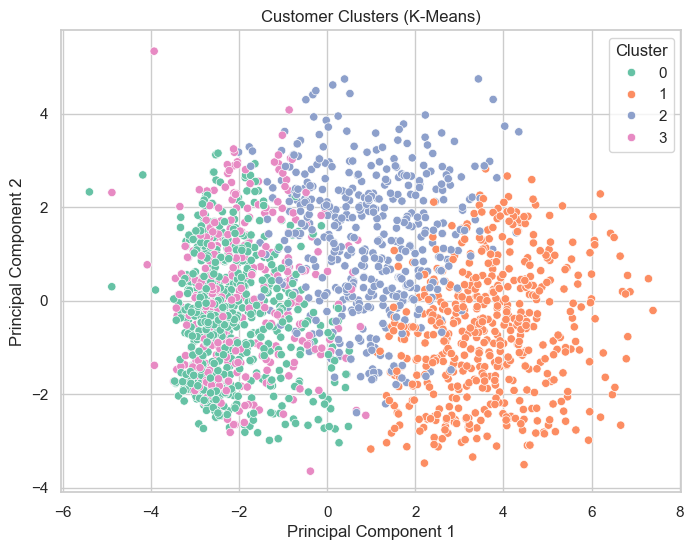

In [106]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca["PC1"],
    y=X_pca["PC2"],
    hue=X_pca["Cluster"],
    palette="Set2"
)

plt.title("Customer Clusters (K-Means)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.show()

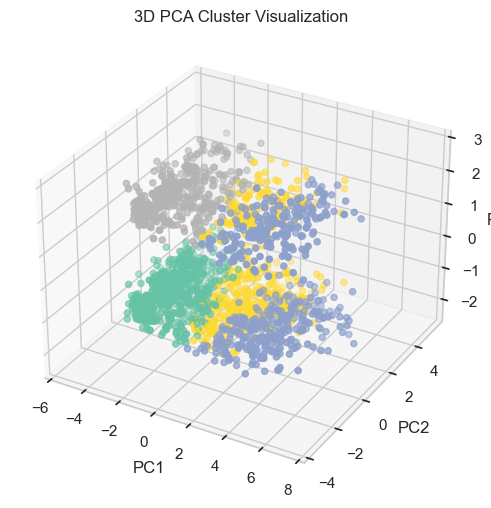

In [107]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    X_pca["PC3"],
    c=kmeans_labels,
    cmap="Set2"
)

ax.set_title("3D PCA Cluster Visualization")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

### Cluster Visualization Insights

The PCA-based visualization above shows how customers are grouped into different clusters using the K-Means algorithm.

Each point represents a customer, and colors indicate the cluster assignment.

From the plots we observe:

* The clusters show **distinct groupings along the principal components**, especially along the first principal component (PC1).
* Some overlap exists between clusters, which is expected in real-world behavioral data where customer behaviors are not perfectly separable.
* The clusters appear **relatively balanced**, suggesting that the algorithm did not collapse into highly uneven groups.

The 3D visualization further confirms that the clustering algorithm has identified meaningful structure in the dataset, separating customers based on differences in their spending patterns, income, and purchasing behavior.

These visualizations provide confidence that the clustering results can be used to analyze and interpret customer segments.


## Cluster Analysis

After assigning cluster labels to each customer, we analyze the characteristics of each cluster to understand how customer groups differ from one another.

Cluster analysis helps identify patterns in customer behavior such as:

* Spending habits
* Income levels
* Purchase frequency
* Website engagement
* Household composition

By calculating the **average values of key features within each cluster**, we can interpret the behavior of each group and identify distinct customer segments.

These insights can then be used to design **targeted marketing strategies and personalized engagement campaigns**.


In [108]:
# Calculate average values for each cluster
cluster_summary = df.groupby("KMeans_Cluster").mean()

cluster_summary

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,Total_Spending,Total_Children,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Living_With_Alone,Living_With_Partner,Agglomerative_Cluster
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,36950.787736,48.622642,58.330189,5.907008,27.475741,9.133423,5.923181,15.812668,2.063342,2.307278,...,122.582210,1.219677,0.115903,0.044474,0.481132,0.172507,0.185984,0.000000,1.000000,0.257412
1,76130.280859,49.393560,596.155635,69.361360,464.946333,102.175313,70.672630,76.472272,1.275492,5.042934,...,1379.783542,0.194991,0.096601,0.000000,0.576029,0.135957,0.191413,0.398927,0.601073,1.803220
2,59485.811508,50.426587,541.682540,25.047619,156.918651,32.023810,27.466270,70.198413,3.890873,6.934524,...,853.337302,1.144841,0.049603,0.001984,0.444444,0.192460,0.311508,0.277778,0.722222,1.119048
3,37612.261021,48.074246,70.740139,6.897912,32.473318,9.044084,6.515081,19.686775,2.310905,2.584687,...,145.357309,1.241299,0.083527,0.046404,0.517401,0.160093,0.192575,1.000000,0.000000,0.294664


In [109]:
# Number of customers in each cluster
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    742
1    559
2    504
3    431
Name: count, dtype: int64

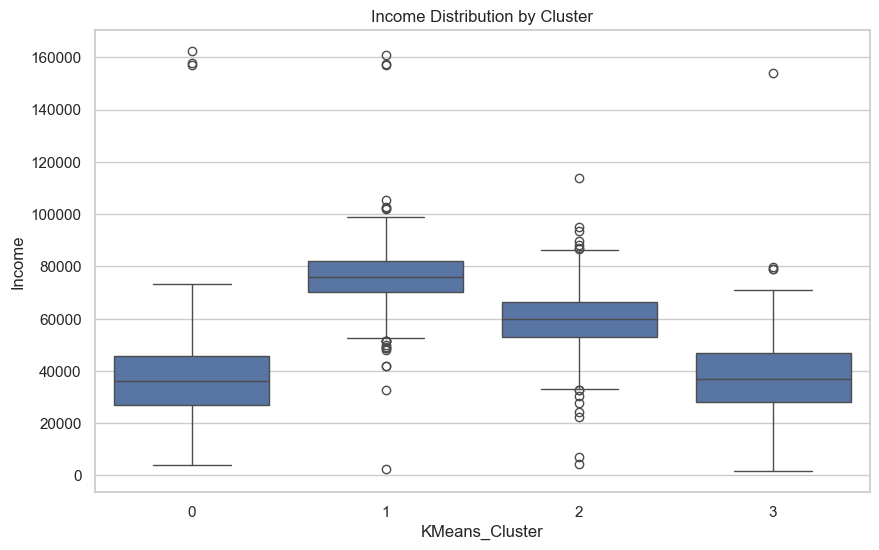

In [110]:
plt.figure()

sns.boxplot(
    x="KMeans_Cluster",
    y="Income",
    data=df
)

plt.title("Income Distribution by Cluster")

plt.show()

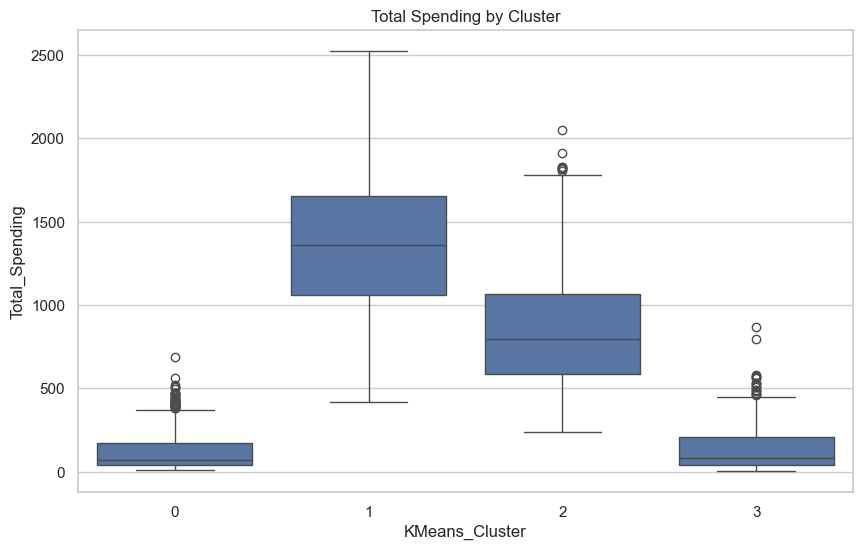

In [111]:
plt.figure()

sns.boxplot(
    x="KMeans_Cluster",
    y="Total_Spending",
    data=df
)

plt.title("Total Spending by Cluster")

plt.show()

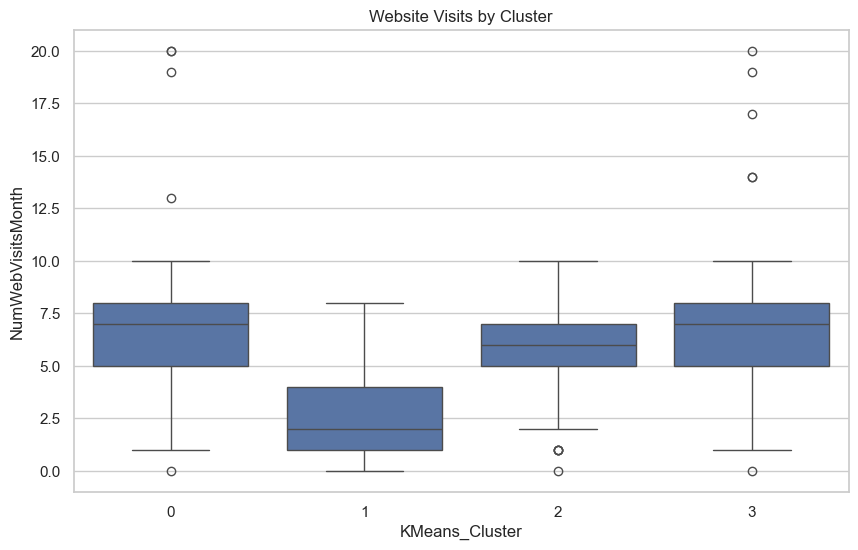

In [112]:
plt.figure()

sns.boxplot(
    x="KMeans_Cluster",
    y="NumWebVisitsMonth",
    data=df
)

plt.title("Website Visits by Cluster")

plt.show()

### Cluster Analysis and Customer Segmentation Insights

The boxplots above highlight clear behavioral differences among the identified customer clusters. By comparing income levels, spending patterns, and website activity, we can interpret the characteristics of each customer group.

**Cluster 0 – Low Spending Couples**
Customers in this cluster generally have lower to moderate income and very low total spending. However, they tend to visit the website relatively frequently. An interesting observation is that customers in this cluster predominantly **live with a partner**, suggesting household-based browsing behavior without significant purchasing activity.

**Cluster 1 – High Value Customers**
This cluster contains customers with the **highest income and the highest total spending**. Despite their high purchasing power, they tend to visit the website less frequently compared to other clusters, indicating that they may already know what they want to purchase and make more targeted transactions.

**Cluster 2 – Regular Customers**
Customers in this segment have **moderate income and moderate spending behavior**. Their website activity is also balanced, suggesting consistent engagement with the platform. This group represents stable customers who contribute regularly to overall sales.

**Cluster 3 – Low Spending Singles**
This cluster is characterized by customers with relatively low income and low spending levels. Similar to Cluster 0, they show moderate to high website activity. However, a key difference is that customers in this cluster predominantly **live alone**, indicating a demographic distinction between clusters that may influence purchasing behavior.

Overall, the clustering results reveal that customer behavior is influenced not only by income and spending patterns but also by demographic characteristics such as **household composition**. These insights can help businesses design more targeted marketing strategies for different customer segments.


## Business Insights and Marketing Strategy

Customer segmentation allows businesses to design targeted strategies for different groups of customers rather than applying a single marketing approach to everyone.

Based on the clustering results and behavioral analysis, the following actionable insights and strategies can be derived for SmartCart.

### Cluster 0 – Low Spending Couples

Customers in this cluster frequently visit the website but show relatively low spending behavior. Since most customers in this group live with a partner, their browsing behavior may reflect household decision-making.

**Business Strategy:**

* Offer **bundle discounts for household products**
* Use **limited-time promotions** to encourage purchases
* Provide **personalized product recommendations**

### Cluster 1 – High Value Customers

This cluster represents the most valuable customers, with the highest income and spending levels. They make fewer website visits but purchase high-value products.

**Business Strategy:**

* Provide **premium loyalty programs**
* Offer **exclusive early access to new products**
* Deliver **personalized premium recommendations**

### Cluster 2 – Regular Customers

Customers in this cluster demonstrate balanced purchasing behavior with moderate income and spending levels. They represent a stable customer base for the platform.

**Business Strategy:**

* Encourage **repeat purchases through loyalty rewards**
* Offer **cross-selling recommendations**
* Promote **membership or subscription programs**

### Cluster 3 – Low Spending Singles

Customers in this group tend to have lower spending but moderate website activity. Most customers in this cluster live alone, suggesting different consumption patterns compared to household customers.

**Business Strategy:**

* Offer **personalized discounts or student offers**
* Promote **individual product recommendations**
* Use **targeted email marketing campaigns**

Overall, these strategies allow SmartCart to move from a **generic marketing approach** to a **data-driven customer engagement strategy**, improving both customer satisfaction and business revenue.


## Conclusion

In this project, we developed a **customer segmentation system for SmartCart** using unsupervised machine learning techniques. The goal was to analyze customer behavior and group customers into meaningful segments based on their demographics, purchasing activity, and engagement patterns.

The project followed a complete data science workflow, including:

* Data exploration and preprocessing
* Feature engineering to create meaningful behavioral variables
* Encoding categorical variables and scaling numerical features
* Dimensionality reduction using **Principal Component Analysis (PCA)**
* Determining the optimal number of clusters using the **Elbow Method** and **Silhouette Score**
* Applying clustering algorithms such as **K-Means** and **Agglomerative Clustering**
* Interpreting and visualizing the resulting customer segments

The clustering process successfully identified **four distinct customer segments**, each exhibiting different characteristics in terms of income, spending behavior, website engagement, and household composition.

These insights demonstrate how machine learning can help businesses move from a **generic marketing strategy** to a **data-driven customer segmentation approach**. By understanding the behavioral patterns of different customer groups, companies can design targeted marketing campaigns, improve customer engagement, and optimize resource allocation.

Overall, this project highlights the value of **unsupervised learning techniques in extracting actionable insights from customer data**, enabling smarter decision-making in modern e-commerce platforms.
